# 03: Independence Tests

Constraint-based causal discovery is built on a repeated question:

**Are variables `X` and `Y` independent after conditioning on a set of variables `Z`?**

If the answer is yes, algorithms such as PC and FCI can remove or mark edges. If the answer is no, the variables remain connected under the current conditioning set. This makes conditional independence tests one of the most important pieces of the causal discovery workflow.

We use the synthetic datasets created in lesson 02. Because those datasets have known structural equations and known true graphs, we can connect each p-value to a causal pattern:

- a true direct edge should usually look dependent;
- an indirect path may become independent after conditioning on the right mediators;
- a collider can create dependence after conditioning;
- a test that matches the data type can behave very differently from a mismatched test.

The point is to learn how conditional independence tests become graph-editing decisions.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic graph-discovery datasets with known structural equations and known graph truth to study **Independence Tests**. Known graph truth lets us see when an algorithm recovers edges, misses edges, or invents edges under violated assumptions.

Read each row as a draw from a structural causal system. Columns are observed variables, and in some lessons omitted latent variables, environments, time ordering, or non-Gaussian mechanisms are deliberately introduced. The experiment studies conditional independence decisions. P-values are interpreted as graph-search evidence within the discovery workflow.

The goal is to learn what each discovery method assumes and how its output should be audited.


## Mathematical Foundation

<!-- math-foundation-note -->

Constraint-based discovery depends on conditional independence testing. In the Gaussian case, testing $X_i \perp\!\!\!\perp X_j \mid S$ is equivalent to testing

$$
H_0: \rho_{ij\cdot S}=0.
$$

The Fisher z statistic is commonly written as

$$
Z=\frac{1}{2}\log\left(\frac{1+r_{ij\cdot S}}{1-r_{ij\cdot S}}\right)\sqrt{n-|S|-3}.
$$

A retained edge means the test did not find a separating set at the tested level. It is not proof of a direct causal effect.



We will build the independence-testing workflow step by step:

1. Set up imports, paths, and causal-learn's `CIT` interface.
2. Load the synthetic datasets and true edge tables from lesson 02.
3. Review which test belongs to which data regime.
4. Run Fisher-Z tests on the linear Gaussian dataset.
5. Study path blocking, collider opening, alpha sensitivity, sample size, and conditioning-set size.
6. Compare Fisher-Z with KCI on nonlinear dependence.
7. Run chi-square and G-square tests on the discrete dataset.
8. Use missing-value Fisher-Z on a controlled missingness example.
9. Save results and close with practical reporting guidance.

Later PC and FCI lessons will use these same test families inside graph-search algorithms.





## Tutorial Workflow

#### Setup

The code below imports the scientific stack, prepares output folders, loads causal-learn's conditional independence test factory, and defines a few display helpers. The `MPLCONFIGDIR` line is set before importing matplotlib so execution does not try to write cache files outside the workspace.


In [1]:
# Define reusable helpers for the Setup section.
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version
import os
import warnings
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from causallearn.utils.cit import CIT
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 0)
pd.set_option("display.max_colwidth", 140)
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "causal_learn":
    NOTEBOOK_DIR = Path("notebooks/tutorials/causal_learn").resolve()
else:
    NOTEBOOK_DIR = NOTEBOOK_DIR.resolve()
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DATASET_DIR = OUTPUT_DIR / "datasets"
for directory in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, DATASET_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
NOTEBOOK_PREFIX = "03"
RANDOM_SEED = 42
ALPHA = 0.05
def pkg_version(package_name: str) -> str:
    """
    Return a package version string without failing if package metadata is unavailable.
    
    Parameters
    ----------
    package_name : str
        Package name to look up in Python package metadata.
    
    Returns
    -------
    str
        Installed package version, or `not installed` when the package cannot be found.
    """
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "not installed"
version_table = pd.DataFrame(
    [
        {"package": "causal-learn", "version": pkg_version("causal-learn")},
        {"package": "numpy", "version": pkg_version("numpy")},
        {"package": "pandas", "version": pkg_version("pandas")},
        {"package": "matplotlib", "version": pkg_version("matplotlib")},
        {"package": "seaborn", "version": pkg_version("seaborn")},
    ]
)
version_table


,package,version
0,causal-learn,0.1.4.5
1,numpy,2.4.4
2,pandas,3.0.2
3,matplotlib,3.10.9
4,seaborn,0.13.2


The version table anchors the test behavior to a concrete environment. Conditional independence tests can have implementation details such as caching, numerical tolerances, and kernel defaults, so recording versions is a small but valuable reproducibility habit.


#### Load the Synthetic Datasets

Lesson 02 generated several datasets under `outputs/datasets`. This lesson loads the ones needed for independence-test examples:

- `linear_gaussian`: friendly baseline for Fisher-Z.
- `nonlinear_continuous`: nonlinear mechanisms where linear tests can be limited.
- `discrete_mixed`: binary and ordinal variables for chi-square and G-square tests.
- `hidden_confounder_observed`: observed-only data with an omitted common cause.

If this step fails because a file is missing, run lesson 02 first.


In [2]:
dataset_paths = {
    "linear_gaussian": DATASET_DIR / "02_linear_gaussian.csv",
    "nonlinear_continuous": DATASET_DIR / "02_nonlinear_continuous.csv",
    "discrete_mixed": DATASET_DIR / "02_discrete_mixed.csv",
    "hidden_confounder_observed": DATASET_DIR / "02_hidden_confounder_observed.csv",
}
missing_files = [str(path) for path in dataset_paths.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Synthetic datasets are missing. Run notebook 02 first. Missing files: " + ", ".join(missing_files)
    )
datasets = {name: pd.read_csv(path) for name, path in dataset_paths.items()}
base_edge_table = pd.read_csv(TABLE_DIR / "02_base_true_dag_edges.csv")
variable_dictionary = pd.read_csv(TABLE_DIR / "02_variable_dictionary.csv")
base_nodes = ["need", "intent", "match", "engagement", "renewal", "support"]
loaded_summary = pd.DataFrame(
    [
        {
            "dataset_name": name,
            "rows": data.shape[0],
            "columns": data.shape[1],
            "column_list": ", ".join(data.columns),
        }
        for name, data in datasets.items()
    ]
)
loaded_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_loaded_dataset_summary.csv", index=False)
loaded_summary


,dataset_name,rows,columns,column_list
0,linear_gaussian,2500,6,"need, intent, match, engagement, renewal, support"
1,nonlinear_continuous,2500,6,"need, intent, match, engagement, renewal, support"
2,discrete_mixed,2500,6,"need, intent, match, engagement, renewal, support"
3,hidden_confounder_observed,2500,6,"need, intent, match, engagement, renewal, support"


The loaded datasets all have the expected observed variables. The discrete dataset uses integer-valued columns, while the continuous datasets are standardized numeric signals.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->


### Test Selection Guide

causal-learn exposes conditional independence tests through `CIT(data, method)`. The method choice should match the data and assumptions. A mismatched test can produce confident-looking p-values for the wrong question.


| method_name | data_type | main_assumption | typical_use | caution |
| --- | --- | --- | --- | --- |
| fisherz | continuous | Approximately linear Gaussian relationships after conditioning. | PC on continuous Gaussian-style tabular data. | Can miss nonlinear dependence and can be sensitive to conditioning-set size. |
| mv_fisherz | continuous with missing values | Fisher-Z style test with missing-value handling. | PC-style workflows when data have missing entries. | Missingness assumptions still matter; the correction only addresses the missingness pattern it is designed for. |
| chisq | discrete | Counts in contingency tables are informative enough for chi-square approximations. | Binary or categorical discovery examples. | Sparse categories and large conditioning sets can make the approximation weak. |
| gsq | discrete | Likelihood-ratio version of a discrete conditional independence test. | Alternative to chi-square for categorical data. | Still depends on enough observations per conditioned cell. |
| kci | continuous or mixed numeric | Kernel-based dependence test can detect nonlinear relationships. | Nonlinear discovery examples and robustness checks. | More computationally expensive; kernel choices and sample size matter. |


This table is the decision layer before any algorithm call. For example, using Fisher-Z on binary variables may run, but it does not mean the resulting p-values answer the intended discrete conditional-independence question.


#### Helper Functions for Running Tests

The `CIT` object expects numeric column indices, not column names. The helper below lets us write tests using variable names and conditioning-set names. It returns p-values and a plain decision at a chosen alpha level.


In [3]:
# Define reusable helpers for the Helper Functions For Running Tests section.
def make_ci_runner(dataframe, columns, method):
    """
    Create a named-column wrapper around causal-learn's CIT interface.
    
    Parameters
    ----------
    dataframe : pd.DataFrame
        Rows and variables used by the current test or estimator.
    columns : list[str]
        Column names included in the test, transformation, or model input.
    method : str
        Method name passed to the estimator, test, or graph algorithm.
    
    Returns
    -------
    callable
        Conditional-independence test runner with the data matrix and selected test method already bound.
    """
    matrix = dataframe[columns].to_numpy()
    column_to_index = {column: position for position, column in enumerate(columns)}
    ci_test = CIT(matrix, method)
    def run_test(x, y, conditioning_set=()):
        """
        Idea: Run one conditional independence test by variable name and return the p-value with a decision label.
        
        Parameters
        ----------
        x : str or array-like
            First variable, column name, or numeric input in the comparison.
        y : str or array-like
            Outcome, second variable, or numeric input in the comparison.
        conditioning_set : object
            Variables conditioned on in the independence test.
        
        Returns
        -------
        dict[str, object]
            Conditional-independence test row with variables, conditioning set, p-value, and decision.
        """
        conditioning_set = tuple(conditioning_set)
        x_idx = column_to_index[x]
        y_idx = column_to_index[y]
        z_idx = tuple(column_to_index[z] for z in conditioning_set)
        p_value = float(ci_test(x_idx, y_idx, z_idx))
        return p_value
    return run_test
def decision_from_p_value(p_value, alpha=ALPHA):
    """
    Translate a p-value into the graph-search decision language.
    
    Parameters
    ----------
    p_value : float
        P-value returned by an independence test.
    alpha : float
        Significance level for an independence test or transparency level for plotting.
    
    Returns
    -------
    str
        Decision label for the independence test at the chosen alpha level.
    """
    return "reject independence" if p_value < alpha else "do not reject independence"
def p_value_label(p_value):
    """
    Format tiny p-values without losing the fact that they are very small.
    
    Parameters
    ----------
    p_value : float
        P-value returned by an independence test.
    
    Returns
    -------
    str
        Readable text representation produced by p value label.
    """
    if p_value == 0:
        return "<1e-300"
    if p_value < 0.001:
        return f"{p_value:.2e}"
    return f"{p_value:.3f}"
PLOT_LOG_CAP = 20
def capped_minus_log10(values, cap=PLOT_LOG_CAP):
    """
    Convert p-values to -log10 scale while capping extremes for readable plots.
    
    Parameters
    ----------
    values : array-like
        Numeric values transformed, standardized, summarized, or plotted by the helper.
    cap : float
        Maximum plotted value after the transformation.
    
    Returns
    -------
    pd.Series or np.ndarray
        Capped negative log10 transform used to make small p-values plottable.
    """
    transformed = -np.log10(pd.Series(values).replace(0, np.nextafter(0, 1)))
    return transformed.clip(upper=cap)
"helpers ready"


'helpers ready'

The decision phrase mirrors constraint-based discovery. A very small p-value means the test rejects the null of conditional independence, so an algorithm would usually keep the variables connected for that conditioning set. A large p-value means the test does not reject independence, so an algorithm may remove an edge or record a separating set.


#### The True Edge Table

Before testing, we inspect the base true graph again. The most important thing to remember is that pairwise association does not equal a direct edge. Variables can be associated through chains, forks, or opened colliders.


In [4]:
base_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_base_true_edges_used.csv", index=False)
base_edge_table


,source,target,edge_type,mechanism
0,need,match,directed,Need changes what a good match means.
1,intent,match,directed,Current intent changes recommendation relevance.
2,match,engagement,directed,Better matching increases engagement depth.
3,intent,renewal,directed,Intent directly affects later value.
4,engagement,renewal,directed,Engagement contributes to renewal value.
5,engagement,support,directed,Engagement creates more chances for support contact.


The true edges define what later graph algorithms should recover. Independence tests are the local evidence used to remove impossible adjacencies and orient some structures, but each individual test only answers one local question.


### Fisher-Z on Linear Gaussian Data

Fisher-Z is the friendly baseline for this tutorial because `linear_gaussian` was generated from linear additive equations with Gaussian noise. The test checks whether the partial correlation between two variables is zero after conditioning on a set of variables.

The cases below cover four teaching patterns:

- a direct edge that should be dependent;
- an indirect association that becomes independent after blocking paths;
- two independent roots;
- a collider that creates dependence after conditioning.


In [5]:
linear_runner = make_ci_runner(datasets["linear_gaussian"], base_nodes, "fisherz")
fisherz_cases = [
    {
        "case": "direct edge",
        "x": "need",
        "y": "match",
        "conditioning_set": (),
        "expected_pattern": "dependent because need directly causes match",
    },
    {
        "case": "indirect path before blocking",
        "x": "need",
        "y": "renewal",
        "conditioning_set": (),
        "expected_pattern": "dependent through downstream paths",
    },
    {
        "case": "indirect path after blocking",
        "x": "need",
        "y": "renewal",
        "conditioning_set": ("intent", "match", "engagement"),
        "expected_pattern": "approximately independent after relevant paths are blocked",
    },
    {
        "case": "two root causes marginally",
        "x": "need",
        "y": "intent",
        "conditioning_set": (),
        "expected_pattern": "approximately independent because both are generated as roots",
    },
    {
        "case": "collider opened by conditioning",
        "x": "need",
        "y": "intent",
        "conditioning_set": ("match",),
        "expected_pattern": "dependent after conditioning on their shared child match",
    },
    {
        "case": "non-edge after blocking",
        "x": "need",
        "y": "support",
        "conditioning_set": ("intent", "match", "engagement"),
        "expected_pattern": "approximately independent after paths through match and engagement are blocked",
    },
]
fisherz_results = []
for case in fisherz_cases:
    p_value = linear_runner(case["x"], case["y"], case["conditioning_set"])
    fisherz_results.append(
        {
            **case,
            "conditioning_set": ", ".join(case["conditioning_set"]) or "none",
            "p_value": p_value,
            "p_value_display": p_value_label(p_value),
            "decision_at_0_05": decision_from_p_value(p_value),
        }
    )
fisherz_results = pd.DataFrame(fisherz_results)
fisherz_results.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fisherz_linear_gaussian_cases.csv", index=False)
fisherz_results


,case,x,y,conditioning_set,expected_pattern,p_value,p_value_display,decision_at_0_05
0,direct edge,need,match,none,dependent because need directly causes match,0.000000,<1e-300,reject independence
1,indirect path before blocking,need,renewal,none,dependent through downstream paths,0.000000,<1e-300,reject independence
2,indirect path after blocking,need,renewal,"intent, match, engagement",approximately independent after relevant paths are blocked,0.308830,0.309,do not reject independence
3,two root causes marginally,need,intent,none,approximately independent because both are generated as roots,0.742852,0.743,do not reject independence
4,collider opened by conditioning,need,intent,match,dependent after conditioning on their shared child match,0.000000,<1e-300,reject independence
5,non-edge after blocking,need,support,"intent, match, engagement",approximately independent after paths through match and engagement are blocked,0.215881,0.216,do not reject independence


The table shows why conditioning matters. `need` and `renewal` are strongly associated marginally, but the dependence weakens once we condition on variables that block the relevant paths. The collider example goes the other way: `need` and `intent` are independent as roots, but conditioning on `match` creates dependence.



## Diagnostics and Interpretation

#### Visualize Fisher-Z Decisions

The next plot turns the previous p-values into capped `-log10(p)`. Larger bars mean stronger evidence against independence. The dashed line marks the usual alpha level of 0.05. This visual form is useful because p-values can span many orders of magnitude; exact values remain in the table.


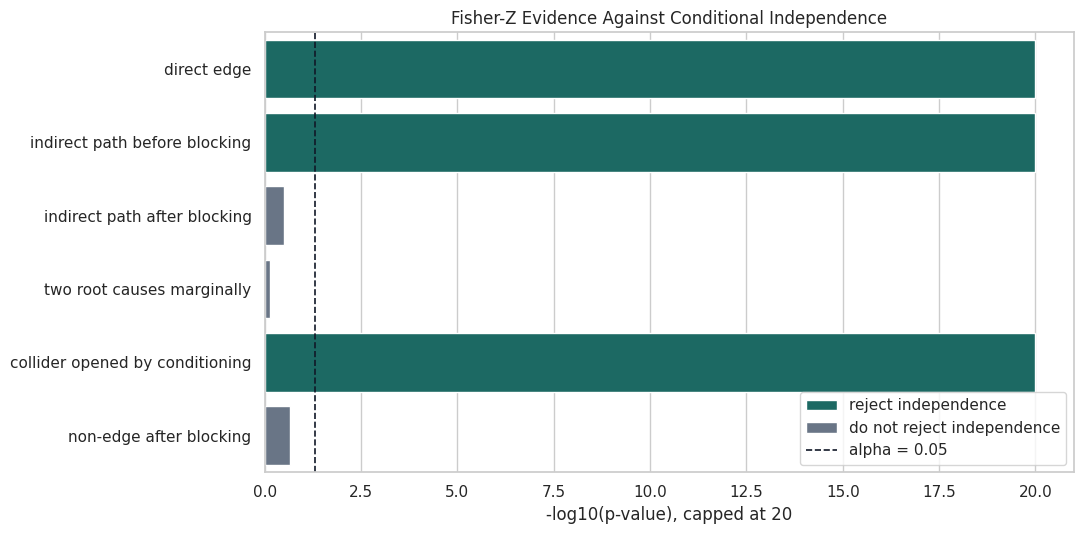

In [6]:
plot_df = fisherz_results.copy()
plot_df["minus_log10_p"] = capped_minus_log10(plot_df["p_value"])
alpha_line = -np.log10(ALPHA)
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(
    data=plot_df,
    x="minus_log10_p",
    y="case",
    hue="decision_at_0_05",
    dodge=False,
    palette={"reject independence": "#0f766e", "do not reject independence": "#64748b"},
    ax=ax,
)
ax.axvline(alpha_line, color="#111827", linestyle="--", linewidth=1.2, label="alpha = 0.05")
ax.set_title("Fisher-Z Evidence Against Conditional Independence")
ax.set_xlabel("-log10(p-value), capped at 20")
ax.set_ylabel("")
ax.set_xlim(0, PLOT_LOG_CAP + 1)
ax.legend(loc="lower right")
plt.tight_layout()
fisherz_bar_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_fisherz_case_decisions.png"
fig.savefig(fisherz_bar_path, dpi=160, bbox_inches="tight")
plt.show()


The visual split is clean: direct or opened paths have very large evidence against independence, while blocked paths and independent roots stay below the decision line. This is the local testing behavior PC-style algorithms depend on.


### Conditioning-Set Size and Path Blocking

A conditioning set can block a path, open a collider, or add noise to the test. The next table follows one pair, `need` and `renewal`, as we add conditioning variables. This pair starts associated because there are directed and backdoor-style paths through the graph.


In [7]:
conditioning_progression = [
    (),
    ("intent",),
    ("match",),
    ("engagement",),
    ("intent", "match"),
    ("intent", "engagement"),
    ("match", "engagement"),
    ("intent", "match", "engagement"),
]
conditioning_rows = []
for conditioning_set in conditioning_progression:
    p_value = linear_runner("need", "renewal", conditioning_set)
    conditioning_rows.append(
        {
            "x": "need",
            "y": "renewal",
            "conditioning_set": ", ".join(conditioning_set) or "none",
            "conditioning_set_size": len(conditioning_set),
            "p_value": p_value,
            "p_value_display": p_value_label(p_value),
            "decision_at_0_05": decision_from_p_value(p_value),
        }
    )
conditioning_path_table = pd.DataFrame(conditioning_rows)
conditioning_path_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_conditioning_set_progression.csv", index=False)
conditioning_path_table


,x,y,conditioning_set,conditioning_set_size,p_value,p_value_display,decision_at_0_05
0,need,renewal,none,0,0.000000,<1e-300,reject independence
1,need,renewal,intent,1,0.000000,<1e-300,reject independence
2,need,renewal,match,1,0.000000,<1e-300,reject independence
3,need,renewal,engagement,1,0.000000,<1e-300,reject independence
4,need,renewal,"intent, match",2,0.185264,0.185,do not reject independence
5,need,renewal,"intent, engagement",2,0.134290,0.134,do not reject independence
6,need,renewal,"match, engagement",2,0.000000,<1e-300,reject independence
7,need,renewal,"intent, match, engagement",3,0.308830,0.309,do not reject independence


The p-value changes as we block more of the relevant paths. The final conditioning set includes `intent`, `match`, and `engagement`, which blocks the main ways `need` and `renewal` are connected in the base graph.


#### Plot the Conditioning Progression

This plot shows the same progression in decision-space. It reinforces a practical point: conditioning is more than “adding controls.” In graphical terms, each variable can block or open a path depending on where it sits in the DAG.


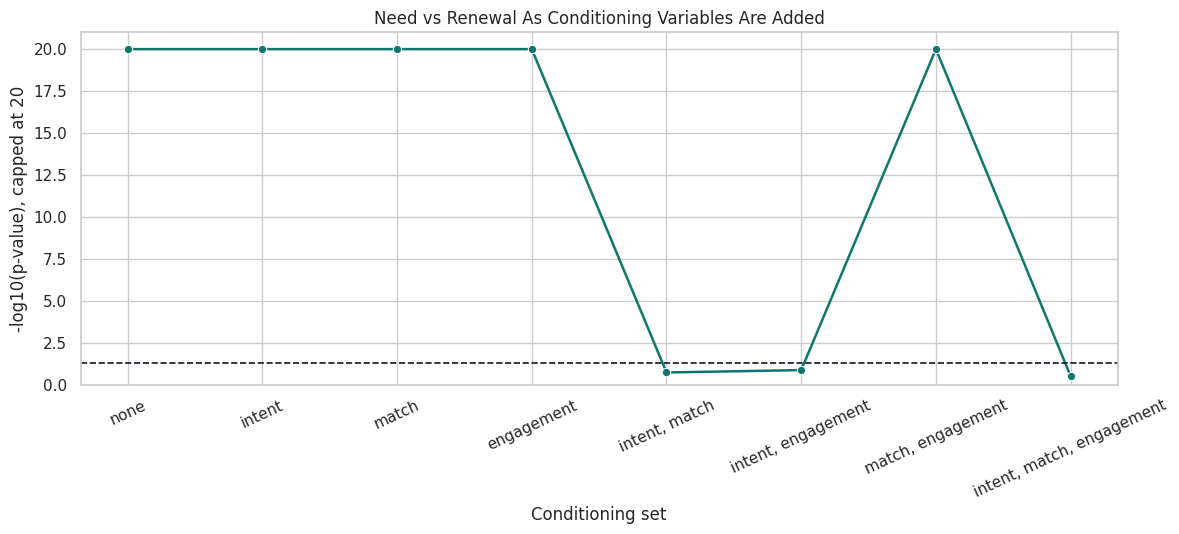

In [8]:
progression_plot = conditioning_path_table.copy()
progression_plot["minus_log10_p"] = capped_minus_log10(progression_plot["p_value"])
fig, ax = plt.subplots(figsize=(12, 5.5))
sns.lineplot(
    data=progression_plot,
    x="conditioning_set",
    y="minus_log10_p",
    marker="o",
    linewidth=1.8,
    color="#0f766e",
    ax=ax,
)
ax.axhline(-np.log10(ALPHA), color="#111827", linestyle="--", linewidth=1.2)
ax.set_title("Need vs Renewal As Conditioning Variables Are Added")
ax.set_xlabel("Conditioning set")
ax.set_ylabel("-log10(p-value), capped at 20")
ax.set_ylim(0, PLOT_LOG_CAP + 1)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
conditioning_plot_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_conditioning_set_progression.png"
fig.savefig(conditioning_plot_path, dpi=160, bbox_inches="tight")
plt.show()


The line drops below the alpha threshold only when the conditioning set blocks enough of the graph. This is why PC searches over many conditioning sets and uses marginal associations only as a starting point.




### Alpha Sensitivity

The alpha threshold controls how easily a test rejects independence. A larger alpha keeps more edges because it rejects independence more often. A smaller alpha removes edges more aggressively. The next step shows decisions for the same Fisher-Z cases under several alpha values.


In [9]:
alpha_values = [0.001, 0.01, 0.05, 0.10]
alpha_rows = []
for _, row in fisherz_results.iterrows():
    for alpha in alpha_values:
        alpha_rows.append(
            {
                "case": row["case"],
                "p_value": row["p_value"],
                "alpha": alpha,
                "decision": decision_from_p_value(row["p_value"], alpha=alpha),
            }
        )
alpha_sensitivity = pd.DataFrame(alpha_rows)
alpha_sensitivity.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_alpha_sensitivity_decisions.csv", index=False)
alpha_sensitivity.pivot(index="case", columns="alpha", values="decision")


alpha,0.001,0.010,0.050,0.100
case,,,,
collider opened by conditioning,reject independence,reject independence,reject independence,reject independence
direct edge,reject independence,reject independence,reject independence,reject independence
indirect path after blocking,do not reject independence,do not reject independence,do not reject independence,do not reject independence
indirect path before blocking,reject independence,reject independence,reject independence,reject independence
non-edge after blocking,do not reject independence,do not reject independence,do not reject independence,do not reject independence
two root causes marginally,do not reject independence,do not reject independence,do not reject independence,do not reject independence


Most clear cases are stable across alpha values, but borderline cases can flip. This is why later graph lessons include alpha sensitivity and report how the graph changes across thresholds.


### Sample Size Sensitivity

Conditional independence tests need enough data. Small samples can fail to detect real dependence or can produce unstable p-values. The code below repeats three Fisher-Z checks across several sample sizes.


In [10]:
sample_cases = [
    {
        "case": "direct edge need-match",
        "x": "need",
        "y": "match",
        "conditioning_set": (),
    },
    {
        "case": "blocked non-edge need-renewal",
        "x": "need",
        "y": "renewal",
        "conditioning_set": ("intent", "match", "engagement"),
    },
    {
        "case": "opened collider need-intent",
        "x": "need",
        "y": "intent",
        "conditioning_set": ("match",),
    },
]
sample_sizes = [100, 250, 500, 1_000, 2_500]
sample_rows = []
linear_data = datasets["linear_gaussian"]
for sample_size in sample_sizes:
    sample_df = linear_data.sample(n=sample_size, random_state=RANDOM_SEED + sample_size)
    sample_runner = make_ci_runner(sample_df, base_nodes, "fisherz")
    for case in sample_cases:
        p_value = sample_runner(case["x"], case["y"], case["conditioning_set"])
        sample_rows.append(
            {
                "sample_size": sample_size,
                "case": case["case"],
                "conditioning_set": ", ".join(case["conditioning_set"]) or "none",
                "p_value": p_value,
                "decision_at_0_05": decision_from_p_value(p_value),
            }
        )
sample_size_sensitivity = pd.DataFrame(sample_rows)
sample_size_sensitivity.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_sample_size_sensitivity.csv", index=False)
sample_size_sensitivity


,sample_size,case,conditioning_set,p_value,decision_at_0_05
0,100,direct edge need-match,none,3.498170e-07,reject independence
1,100,blocked non-edge need-renewal,"intent, match, engagement",2.673226e-01,do not reject independence
2,100,opened collider need-intent,match,0.000000e+00,reject independence
3,250,direct edge need-match,none,0.000000e+00,reject independence
4,250,blocked non-edge need-renewal,"intent, match, engagement",1.185747e-01,do not reject independence
5,250,opened collider need-intent,match,0.000000e+00,reject independence
6,500,direct edge need-match,none,0.000000e+00,reject independence
7,500,blocked non-edge need-renewal,"intent, match, engagement",8.016450e-01,do not reject independence
8,500,opened collider need-intent,match,0.000000e+00,reject independence
9,1000,direct edge need-match,none,0.000000e+00,reject independence


The strongest dependence patterns are usually detected even with smaller samples. The blocked case is more variable because the expected result is “do not reject independence,” which is always harder to prove from finite data.


#### Plot Sample Size Sensitivity

The next plot shows how evidence against independence changes with sample size. The y-axis again uses capped `-log10(p)` so small p-values are visible without letting underflow dominate the scale.


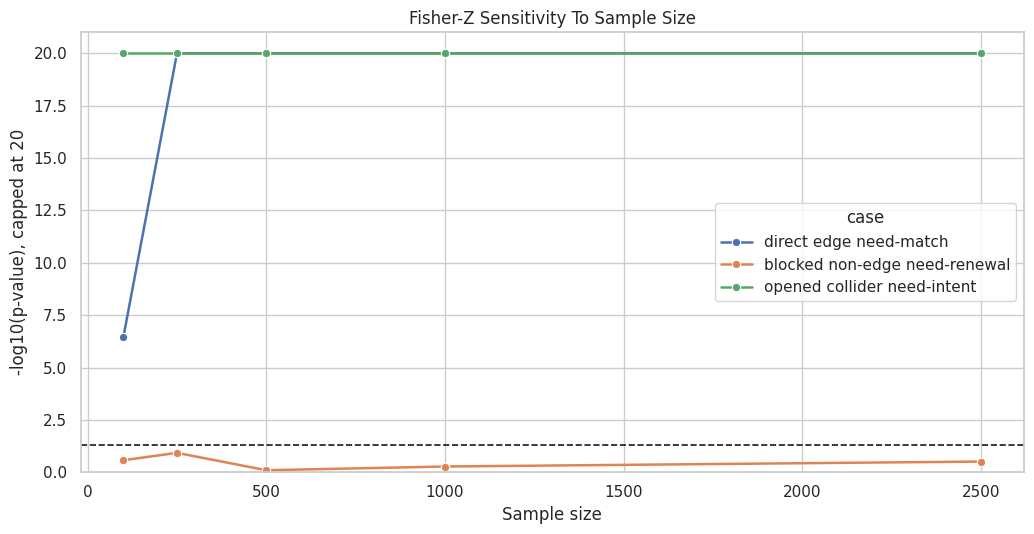

In [11]:
sample_plot = sample_size_sensitivity.copy()
sample_plot["minus_log10_p"] = capped_minus_log10(sample_plot["p_value"])
fig, ax = plt.subplots(figsize=(10.5, 5.5))
sns.lineplot(
    data=sample_plot,
    x="sample_size",
    y="minus_log10_p",
    hue="case",
    marker="o",
    linewidth=1.8,
    ax=ax,
)
ax.axhline(-np.log10(ALPHA), color="#111827", linestyle="--", linewidth=1.2)
ax.set_title("Fisher-Z Sensitivity To Sample Size")
ax.set_xlabel("Sample size")
ax.set_ylabel("-log10(p-value), capped at 20")
ax.set_ylim(0, PLOT_LOG_CAP + 1)
plt.tight_layout()
sample_size_plot_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sample_size_sensitivity.png"
fig.savefig(sample_size_plot_path, dpi=160, bbox_inches="tight")
plt.show()


The plot makes the practical lesson visible: p-values reflect both graph structure and sample size. A discovery graph learned from 100 rows can differ from one learned from 2,500 rows even if the data-generating DAG is identical.




#### Marginal P-Value Matrix

Before running a full algorithm, it is useful to inspect all pairwise marginal tests. This matrix serves a different role than a graph. It reveals which variable pairs are strongly associated before conditioning.


In [12]:
# Define reusable helpers for the Marginal P-Value Matrix section.
def marginal_p_value_matrix(dataframe, columns, method):
    """
    Idea: Compute pairwise marginal independence-test p-values for a selected set of variables.
    
    Parameters
    ----------
    dataframe : pd.DataFrame
        Rows used by this helper.
    columns : list[str]
        Column names included in the transformation, test, or display.
    method : str
        Estimator, test, or algorithm name being run.
    
    Returns
    -------
    pd.DataFrame
        Square matrix of pairwise marginal independence-test p-values.
    """
    runner = make_ci_runner(dataframe, columns, method)
    matrix = pd.DataFrame(np.ones((len(columns), len(columns))), index=columns, columns=columns)
    for i, x in enumerate(columns):
        for j, y in enumerate(columns):
            if i >= j:
                continue
            p_value = runner(x, y, ())
            matrix.loc[x, y] = p_value
            matrix.loc[y, x] = p_value
    return matrix
fisherz_marginal_p = marginal_p_value_matrix(datasets["linear_gaussian"], base_nodes, "fisherz")
fisherz_marginal_p.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fisherz_marginal_p_matrix.csv")
fisherz_marginal_p


,need,intent,match,engagement,renewal,support
need,1.000000,0.742852,0.0,0.0,0.0,0.0
intent,0.742852,1.000000,0.0,0.0,0.0,0.0
match,0.000000,0.000000,1.0,0.0,0.0,0.0
engagement,0.000000,0.000000,0.0,1.0,0.0,0.0
renewal,0.000000,0.000000,0.0,0.0,1.0,0.0
support,0.000000,0.000000,0.0,0.0,0.0,1.0


Many non-adjacent pairs have very small marginal p-values because they are connected through paths in the DAG. This is the reason causal discovery cannot stop at pairwise testing.


#### Heatmap of Marginal Evidence

The heatmap shows the same p-value matrix as capped `-log10(p)`. Bright cells are strong pairwise associations. The diagonal is set to zero because a variable is not tested against itself.


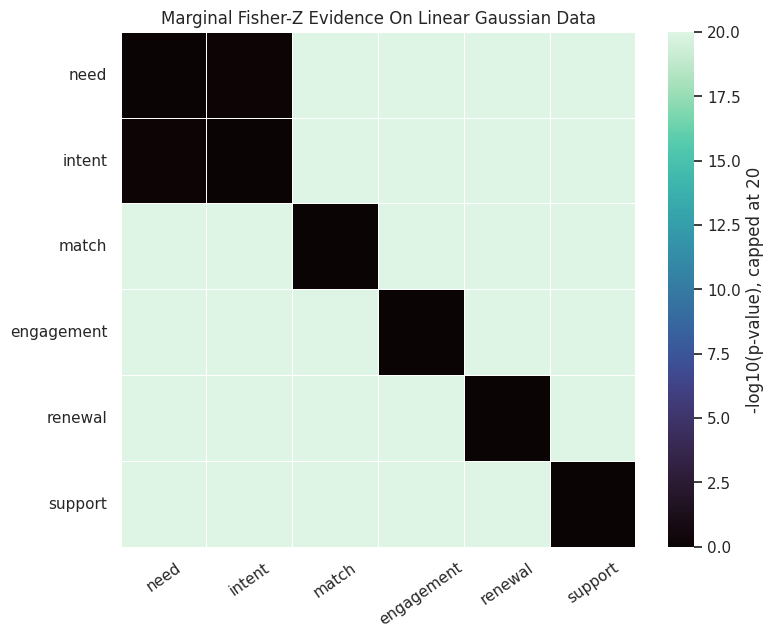

In [13]:
heatmap_values = fisherz_marginal_p.apply(lambda column: capped_minus_log10(column)).copy()
heatmap_array = heatmap_values.to_numpy(copy=True)
np.fill_diagonal(heatmap_array, 0)
heatmap_values = pd.DataFrame(heatmap_array, index=heatmap_values.index, columns=heatmap_values.columns)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    heatmap_values,
    cmap="mako",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "-log10(p-value), capped at 20"},
    ax=ax,
)
ax.set_title("Marginal Fisher-Z Evidence On Linear Gaussian Data")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
marginal_heatmap_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_fisherz_marginal_p_heatmap.png"
fig.savefig(marginal_heatmap_path, dpi=160, bbox_inches="tight")
plt.show()


The heatmap is dense because marginal dependence travels along causal paths. PC-style algorithms become useful because they search for conditioning sets that explain away indirect associations.


#### Nonlinear Dependence: Fisher-Z vs KCI

Fisher-Z is based on partial correlation, so it is naturally tuned to linear dependence. Kernel conditional independence tests can detect broader nonlinear relationships, but they are more expensive. The next demo creates a deliberately simple nonlinear pair: `v = u^2 + noise`. The correlation can be close to zero even though the variables are dependent.


In [14]:
nonlinear_rng = np.random.default_rng(RANDOM_SEED + 200)
nonlinear_demo = pd.DataFrame({"u": nonlinear_rng.normal(size=350)})
nonlinear_demo["v"] = (nonlinear_demo["u"] ** 2 - 1) + nonlinear_rng.normal(scale=0.25, size=len(nonlinear_demo))
nonlinear_demo_corr = nonlinear_demo["u"].corr(nonlinear_demo["v"])
fisherz_pair_runner = make_ci_runner(nonlinear_demo, ["u", "v"], "fisherz")
kci_pair_runner = make_ci_runner(nonlinear_demo, ["u", "v"], "kci")
nonlinear_test_comparison = pd.DataFrame(
    [
        {
            "test": "fisherz",
            "relationship": "u with u^2 + noise",
            "pearson_correlation": nonlinear_demo_corr,
            "p_value": fisherz_pair_runner("u", "v", ()),
        },
        {
            "test": "kci",
            "relationship": "u with u^2 + noise",
            "pearson_correlation": nonlinear_demo_corr,
            "p_value": kci_pair_runner("u", "v", ()),
        },
    ]
)
nonlinear_test_comparison["p_value_display"] = nonlinear_test_comparison["p_value"].map(p_value_label)
nonlinear_test_comparison["decision_at_0_05"] = nonlinear_test_comparison["p_value"].map(decision_from_p_value)
nonlinear_test_comparison.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_nonlinear_fisherz_vs_kci.csv", index=False)
nonlinear_test_comparison


,test,relationship,pearson_correlation,p_value,p_value_display,decision_at_0_05
0,fisherz,u with u^2 + noise,0.021327,0.691117,0.691,do not reject independence
1,kci,u with u^2 + noise,0.021327,0.000000,<1e-300,reject independence


The Fisher-Z p-value does not reject independence because the linear correlation is weak. KCI rejects independence because the nonlinear relationship is real. This is the cleanest reminder that test choice encodes assumptions.


#### Visualize the Nonlinear Pair

The scatterplot makes the previous table obvious. A straight-line correlation test is looking for the wrong shape, while a nonlinear test can detect the curved relationship.


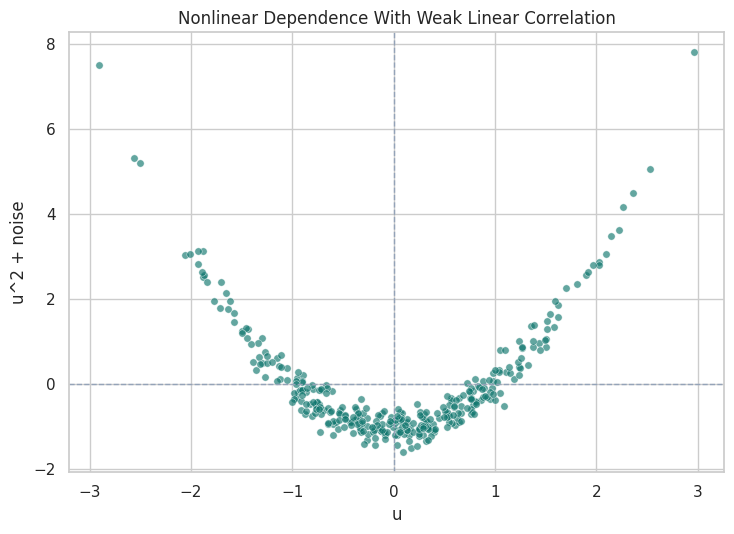

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.scatterplot(data=nonlinear_demo, x="u", y="v", s=28, alpha=0.65, color="#0f766e", ax=ax)
ax.axhline(0, color="#94a3b8", linewidth=1, linestyle="--")
ax.axvline(0, color="#94a3b8", linewidth=1, linestyle="--")
ax.set_title("Nonlinear Dependence With Weak Linear Correlation")
ax.set_xlabel("u")
ax.set_ylabel("u^2 + noise")
plt.tight_layout()
nonlinear_pair_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_nonlinear_pair_demo.png"
fig.savefig(nonlinear_pair_path, dpi=160, bbox_inches="tight")
plt.show()


The curved pattern is visually clear. A future nonlinear-discovery lesson can use this same lesson at graph scale: if the relationship is nonlinear, a linear test may produce misleading local decisions.


#### KCI on the Nonlinear Synthetic Dataset

Now we use KCI on a subset of the nonlinear continuous dataset from lesson 02. KCI is more expensive than Fisher-Z, so this example samples a few hundred rows and tests only a small number of relationships.


In [16]:
nonlinear_sample = datasets["nonlinear_continuous"].sample(n=350, random_state=RANDOM_SEED)
nonlinear_kci_runner = make_ci_runner(nonlinear_sample, base_nodes, "kci")
nonlinear_fisherz_runner = make_ci_runner(nonlinear_sample, base_nodes, "fisherz")
nonlinear_cases = [
    {"case": "true edge need-match", "x": "need", "y": "match", "conditioning_set": ()},
    {"case": "true edge match-engagement", "x": "match", "y": "engagement", "conditioning_set": ()},
    {"case": "blocked need-renewal", "x": "need", "y": "renewal", "conditioning_set": ("intent", "match", "engagement")},
]
nonlinear_ci_rows = []
for case in nonlinear_cases:
    for method_name, runner in [("fisherz", nonlinear_fisherz_runner), ("kci", nonlinear_kci_runner)]:
        p_value = runner(case["x"], case["y"], case["conditioning_set"])
        nonlinear_ci_rows.append(
            {
                "case": case["case"],
                "test": method_name,
                "conditioning_set": ", ".join(case["conditioning_set"]) or "none",
                "p_value": p_value,
                "p_value_display": p_value_label(p_value),
                "decision_at_0_05": decision_from_p_value(p_value),
            }
        )
nonlinear_dataset_test_comparison = pd.DataFrame(nonlinear_ci_rows)
nonlinear_dataset_test_comparison.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_nonlinear_dataset_test_comparison.csv", index=False)
nonlinear_dataset_test_comparison


,case,test,conditioning_set,p_value,p_value_display,decision_at_0_05
0,true edge need-match,fisherz,none,0.000000,<1e-300,reject independence
1,true edge need-match,kci,none,0.000000,<1e-300,reject independence
2,true edge match-engagement,fisherz,none,0.000000,<1e-300,reject independence
3,true edge match-engagement,kci,none,0.000000,<1e-300,reject independence
4,blocked need-renewal,fisherz,"intent, match, engagement",0.221437,0.221,do not reject independence
5,blocked need-renewal,kci,"intent, match, engagement",0.193640,0.194,do not reject independence


The nonlinear dataset is less tidy than the two-variable demo, but the same caution applies. KCI can detect nonlinear dependence, while Fisher-Z is faster and simpler when its assumptions are reasonable.


#### Discrete Data: Chi-Square and G-Square

For discrete variables, causal-learn provides chi-square and G-square conditional independence tests. We use the `discrete_mixed` dataset from lesson 02. The cases mirror the Fisher-Z section, but the method now matches categorical data.


In [17]:
discrete_columns = base_nodes
discrete_chisq_runner = make_ci_runner(datasets["discrete_mixed"], discrete_columns, "chisq")
discrete_gsq_runner = make_ci_runner(datasets["discrete_mixed"], discrete_columns, "gsq")
discrete_cases = [
    {
        "case": "direct edge",
        "x": "need",
        "y": "match",
        "conditioning_set": (),
        "expected_pattern": "dependent because need affects match probability",
    },
    {
        "case": "indirect path before blocking",
        "x": "need",
        "y": "renewal",
        "conditioning_set": (),
        "expected_pattern": "dependent through downstream paths",
    },
    {
        "case": "indirect path after blocking",
        "x": "need",
        "y": "renewal",
        "conditioning_set": ("intent", "match", "engagement"),
        "expected_pattern": "weaker after blocking observed paths",
    },
    {
        "case": "blocked non-edge",
        "x": "need",
        "y": "support",
        "conditioning_set": ("intent", "match", "engagement"),
        "expected_pattern": "approximately independent after blocking paths through engagement",
    },
]
discrete_rows = []
for case in discrete_cases:
    for method_name, runner in [("chisq", discrete_chisq_runner), ("gsq", discrete_gsq_runner)]:
        p_value = runner(case["x"], case["y"], case["conditioning_set"])
        discrete_rows.append(
            {
                **case,
                "test": method_name,
                "conditioning_set": ", ".join(case["conditioning_set"]) or "none",
                "p_value": p_value,
                "p_value_display": p_value_label(p_value),
                "decision_at_0_05": decision_from_p_value(p_value),
            }
        )
discrete_test_results = pd.DataFrame(discrete_rows)
discrete_test_results.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_discrete_chisq_gsq_results.csv", index=False)
discrete_test_results


,case,x,y,conditioning_set,expected_pattern,test,p_value,p_value_display,decision_at_0_05
0,direct edge,need,match,none,dependent because need affects match probability,chisq,1.807196e-40,1.81e-40,reject independence
1,direct edge,need,match,none,dependent because need affects match probability,gsq,4.869422e-41,4.87e-41,reject independence
2,indirect path before blocking,need,renewal,none,dependent through downstream paths,chisq,1.784279e-06,1.78e-06,reject independence
3,indirect path before blocking,need,renewal,none,dependent through downstream paths,gsq,1.749210e-06,1.75e-06,reject independence
4,indirect path after blocking,need,renewal,"intent, match, engagement",weaker after blocking observed paths,chisq,1.751088e-01,0.175,do not reject independence
5,indirect path after blocking,need,renewal,"intent, match, engagement",weaker after blocking observed paths,gsq,1.736190e-01,0.174,do not reject independence
6,blocked non-edge,need,support,"intent, match, engagement",approximately independent after blocking paths through engagement,chisq,4.495724e-01,0.450,do not reject independence
7,blocked non-edge,need,support,"intent, match, engagement",approximately independent after blocking paths through engagement,gsq,4.407588e-01,0.441,do not reject independence


Chi-square and G-square tell the same broad story here. Direct and unblocked paths show dependence, while blocked non-edges are less likely to reject independence. In sparse categorical problems, these two tests can differ more, so both are worth understanding.


#### Discrete Test Decisions Side by Side

This plot compares chi-square and G-square p-values for the discrete cases. It is useful to see whether the two tests agree before using either one inside a full graph search.


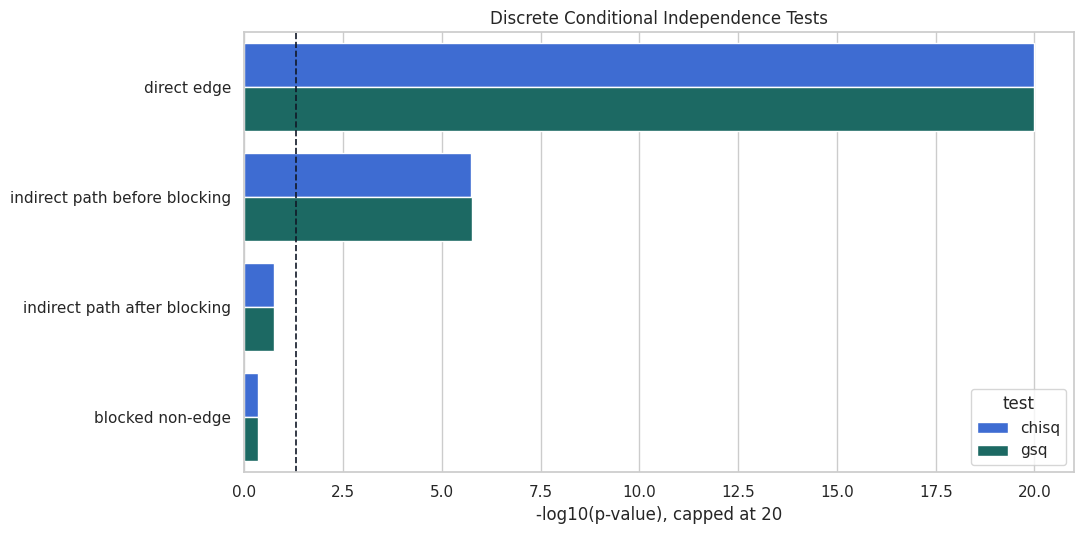

In [18]:
discrete_plot = discrete_test_results.copy()
discrete_plot["minus_log10_p"] = capped_minus_log10(discrete_plot["p_value"])
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(
    data=discrete_plot,
    x="minus_log10_p",
    y="case",
    hue="test",
    palette={"chisq": "#2563eb", "gsq": "#0f766e"},
    ax=ax,
)
ax.axvline(-np.log10(ALPHA), color="#111827", linestyle="--", linewidth=1.2)
ax.set_title("Discrete Conditional Independence Tests")
ax.set_xlabel("-log10(p-value), capped at 20")
ax.set_ylabel("")
ax.set_xlim(0, PLOT_LOG_CAP + 1)
plt.tight_layout()
discrete_plot_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_discrete_chisq_gsq_comparison.png"
fig.savefig(discrete_plot_path, dpi=160, bbox_inches="tight")
plt.show()


The paired bars are close, which is reassuring for this synthetic dataset. The bigger lesson is that the discrete tests are designed for count data, while Fisher-Z is designed for continuous partial correlations.




#### Missing Values and `mv_fisherz`

Real datasets often have missing values. This section creates controlled missingness in the linear Gaussian data and compares two approaches:

- complete-case Fisher-Z, which drops rows with missing values in the variables involved in the test;
- causal-learn's `mv_fisherz`, which is designed for missing-value settings.

This is a worked example, not a universal missing-data solution. Missingness mechanisms still need their own causal thinking.


In [19]:
missing_rng = np.random.default_rng(RANDOM_SEED + 300)
missing_data = datasets["linear_gaussian"].copy()
missing_probability = 0.08
missing_mask = missing_rng.random(missing_data.shape) < missing_probability
missing_data = missing_data.mask(missing_mask)
missing_summary = pd.DataFrame(
    {
        "variable": missing_data.columns,
        "missing_rate": missing_data.isna().mean().values,
        "observed_count": missing_data.notna().sum().values,
    }
)
missing_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_missing_value_summary.csv", index=False)
missing_summary


,variable,missing_rate,observed_count
0,need,0.0756,2311
1,intent,0.0804,2299
2,match,0.0892,2277
3,engagement,0.0796,2301
4,renewal,0.0732,2317
5,support,0.0868,2283


The missing rates are close to the designed 8 percent level. Because the missingness was injected randomly here, it is much simpler than the missingness patterns we would worry about in real data.


#### Compare Complete-Case Fisher-Z and Missing-Value Fisher-Z

The next step runs the same cases under complete-case Fisher-Z and `mv_fisherz`. For complete-case testing, each row must be observed for the pair and conditioning variables in that specific test.


In [20]:
# Define reusable helpers for the Compare Complete-Case Fisher-Z And Missing-Value Fisher-Z section.
def complete_case_fisherz(dataframe, x, y, conditioning_set=()):
    """
    Run Fisher-Z after dropping rows missing any variable needed for this test.
    
    Parameters
    ----------
    dataframe : pd.DataFrame
        Rows and variables used by the current test or estimator.
    x : str or array-like
        First variable, column name, or numeric input in the local calculation.
    y : str or array-like
        Second variable, outcome, or numeric input in the local calculation.
    conditioning_set : list[str]
        Variables conditioned on in the independence test.
    
    Returns
    -------
    tuple
        Tuple containing runner(x, y, conditioning_set), len(complete).
    """
    required_columns = [x, y, *conditioning_set]
    complete = dataframe[required_columns].dropna()
    runner = make_ci_runner(complete, required_columns, "fisherz")
    return runner(x, y, conditioning_set), len(complete)
mv_runner = make_ci_runner(missing_data, base_nodes, "mv_fisherz")
missing_cases = [
    {"case": "direct edge need-match", "x": "need", "y": "match", "conditioning_set": ()},
    {"case": "blocked need-renewal", "x": "need", "y": "renewal", "conditioning_set": ("intent", "match", "engagement")},
    {"case": "opened collider need-intent", "x": "need", "y": "intent", "conditioning_set": ("match",)},
]
missing_test_rows = []
for case in missing_cases:
    cc_p_value, cc_rows = complete_case_fisherz(missing_data, case["x"], case["y"], case["conditioning_set"])
    mv_p_value = mv_runner(case["x"], case["y"], case["conditioning_set"])
    missing_test_rows.extend(
        [
            {
                "case": case["case"],
                "approach": "complete_case_fisherz",
                "rows_used": cc_rows,
                "conditioning_set": ", ".join(case["conditioning_set"]) or "none",
                "p_value": cc_p_value,
                "p_value_display": p_value_label(cc_p_value),
                "decision_at_0_05": decision_from_p_value(cc_p_value),
            },
            {
                "case": case["case"],
                "approach": "mv_fisherz",
                "rows_used": len(missing_data),
                "conditioning_set": ", ".join(case["conditioning_set"]) or "none",
                "p_value": mv_p_value,
                "p_value_display": p_value_label(mv_p_value),
                "decision_at_0_05": decision_from_p_value(mv_p_value),
            },
        ]
    )
missing_test_comparison = pd.DataFrame(missing_test_rows)
missing_test_comparison.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_missing_value_fisherz_comparison.csv", index=False)
missing_test_comparison


,case,approach,rows_used,conditioning_set,p_value,p_value_display,decision_at_0_05
0,direct edge need-match,complete_case_fisherz,2101,none,0.000000,<1e-300,reject independence
1,direct edge need-match,mv_fisherz,2500,none,0.000000,<1e-300,reject independence
2,blocked need-renewal,complete_case_fisherz,1659,"intent, match, engagement",0.113165,0.113,do not reject independence
3,blocked need-renewal,mv_fisherz,2500,"intent, match, engagement",0.113165,0.113,do not reject independence
4,opened collider need-intent,complete_case_fisherz,1940,match,0.000000,<1e-300,reject independence
5,opened collider need-intent,mv_fisherz,2500,match,0.000000,<1e-300,reject independence


The two approaches agree on the broad teaching patterns here. The complete-case row count drops most when the conditioning set is larger, which is one reason missingness can become more damaging in high-dimensional discovery.




#### Conditioning Set Size and Data Requirements

The number of possible conditioning sets grows quickly with the number of variables. Even before running PC, we can count how many candidate sets exist at each size for a pair of variables. This shows why constraint-based discovery can become expensive as graphs grow.


In [21]:
from math import comb
n_variables = len(base_nodes)
conditioning_count_rows = []
for conditioning_size in range(n_variables - 1):
    available_variables = n_variables - 2
    count_for_one_pair = comb(available_variables, conditioning_size) if conditioning_size <= available_variables else 0
    conditioning_count_rows.append(
        {
            "conditioning_set_size": conditioning_size,
            "candidate_sets_for_one_pair": count_for_one_pair,
            "why_it_matters": "More sets mean more tests and more chances for finite-sample instability.",
        }
    )
conditioning_set_counts = pd.DataFrame(conditioning_count_rows)
conditioning_set_counts.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_conditioning_set_counts.csv", index=False)
conditioning_set_counts


,conditioning_set_size,candidate_sets_for_one_pair,why_it_matters
0,0,1,More sets mean more tests and more chances for finite-sample instability.
1,1,4,More sets mean more tests and more chances for finite-sample instability.
2,2,6,More sets mean more tests and more chances for finite-sample instability.
3,3,4,More sets mean more tests and more chances for finite-sample instability.
4,4,1,More sets mean more tests and more chances for finite-sample instability.


With six variables this is still tiny. With dozens or hundreds of variables, the search space becomes a real computational and statistical problem. This is why practical discovery workflows often use prior knowledge, variable screening, or stability checks.





## Reporting and Takeaways

### What to Report with Independence Tests

This final guide summarizes what should be reported when conditional independence tests support a causal discovery graph. It is not enough to say “we ran PC.” A useful report should name the test, data type, alpha level, conditioning strategy, and sensitivity checks.


| report_item | example | why_it_matters |
| --- | --- | --- |
| Test family | Fisher-Z for continuous linear Gaussian-style data | The test defines what kind of independence claim is being evaluated. |
| Data type match | Chi-square or G-square for discrete variables | A mismatched test can produce misleading graph edits. |
| Alpha threshold | alpha = 0.01, 0.05, and 0.10 sensitivity | Graph structure can change when the rejection threshold changes. |
| Conditioning-set limits | Maximum conditioning size used by the algorithm | Larger sets require more data and more tests. |
| Missing-data handling | Complete-case Fisher-Z versus mv_fisherz | Missingness can change sample size and induce bias. |
| Nonlinear robustness | KCI check on suspected nonlinear relationships | Linear tests can miss nonlinear dependence. |


This guide turns the technical test calls into a reporting checklist. A graph is easier to trust when the independence-test assumptions and sensitivity checks are visible.


## Summary


With the independence-test layer in place, the PC workflow can run on continuous data and show why edges are removed, why some directions remain unresolved, and why alpha sensitivity matters.
